In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from model import (
    homogeneous_model,
    two_layer_model,
    layered_model,
    fault_model,
    linear_gradient_model,
    circular_anomaly_model,
    rectangular_anomaly_model,
    dipping_layer_model,
    sinusoidal_interface_model,
    depression_model,
    salt_model,
    checkerboard_model
)

In [2]:
# Grid parameters
nx = 401
nz = 301
dx = 10.0
dz = 10.0
x_max = (nx - 1) * dx
z_max = (nz - 1) * dz

In [3]:
# 1. Homogeneous model
vel_homo = homogeneous_model(
    nx=nx,
    nz=nz,
    velocity=2500.0)

# 2. Two-layer model
vel_two_layer = two_layer_model(
    nx=nx,
    nz=nz,
    dz=dz,
    interface_depth=1500.0,
    velocity_top=2000.0,
    velocity_bottom=3200.0
)

# 3. Multi-layer model
vel_layered = layered_model(
    nx=nx,
    nz=nz,
    dz=dz,
    interfaces=[
        700.0,
        1500.0,
        2300.0
    ],
    velocities=[
        1800.0,
        2300.0,
        3000.0,
        3800.0
    ]
)

# 4. Fault model
vel_fault = fault_model(
    nx=nx,
    nz=nz,
    dx=dx,
    dz=dz,
    interfaces=[
        800.0,
        1700.0
    ],
    velocities=[
        1900.0,
        2600.0,
        3400.0
    ],
    fault_x=2000.0,
    fault_throw=500.0
)

# 5. Linear gradient model
vel_gradient = linear_gradient_model(
    nx=nx,
    nz=nz,
    dz=dz,
    velocity_top=1500.0,
    gradient=0.7
)

# 6. Circular anomaly model
vel_circle = circular_anomaly_model(
    nx=nx,
    nz=nz,
    dx=dx,
    dz=dz,
    background_velocity=2500.0,
    anomaly_velocity=3500.0,
    center_x=2000.0,
    center_z=1500.0,
    radius=500.0
)

# 7. Rectangular anomaly model
vel_rectangle = rectangular_anomaly_model(
    nx=nx,
    nz=nz,
    dx=dx,
    dz=dz,
    background_velocity=2500.0,
    anomaly_velocity=1800.0,
    x_min=1300.0,
    x_max=2800.0,
    z_min=1000.0,
    z_max=2000.0
)

# 8. Dipping layer model
vel_dipping = dipping_layer_model(
    nx=nx,
    nz=nz,
    dx=dx,
    dz=dz,
    velocity_top=2000.0,
    velocity_bottom=3200.0,
    depth0=700.0,
    angle=15.0
)

# 9. Sinusoidal interface model
vel_sinusoidal = sinusoidal_interface_model(
    nx=nx,
    nz=nz,
    dx=dx,
    dz=dz,
    velocity_top=2000.0,
    velocity_bottom=3200.0,
    depth0=1500.0,
    amplitude=300.0,
    wavelength=1000.0
)

# 10. Depression model
vel_depression = depression_model(
    nx=nx,
    nz=nz,
    dx=dx,
    dz=dz,
    velocity_top=2000.0,
    velocity_bottom=3200.0,
    depth0=1000.0,
    center_x=2000.0,
    depth_amplitude=800.0,
    width=700.0
)

# 11. Salt model
vel_salt = salt_model(
    nx=nx,
    nz=nz,
    dx=dx,
    dz=dz,
    background_velocity=2500.0,
    salt_velocity=4500.0,
    center_x=2000.0,
    center_z=1600.0,
    radius_x=700.0,
    radius_z=1100.0
)

# 12. Checkerboard model
vel_checkerboard = checkerboard_model(
    nx=nx,
    nz=nz,
    dx=dx,
    dz=dz,
    background_velocity=2500.0,
    velocity_perturbation=400.0,
    block_width=500.0,
    block_height=500.0
)

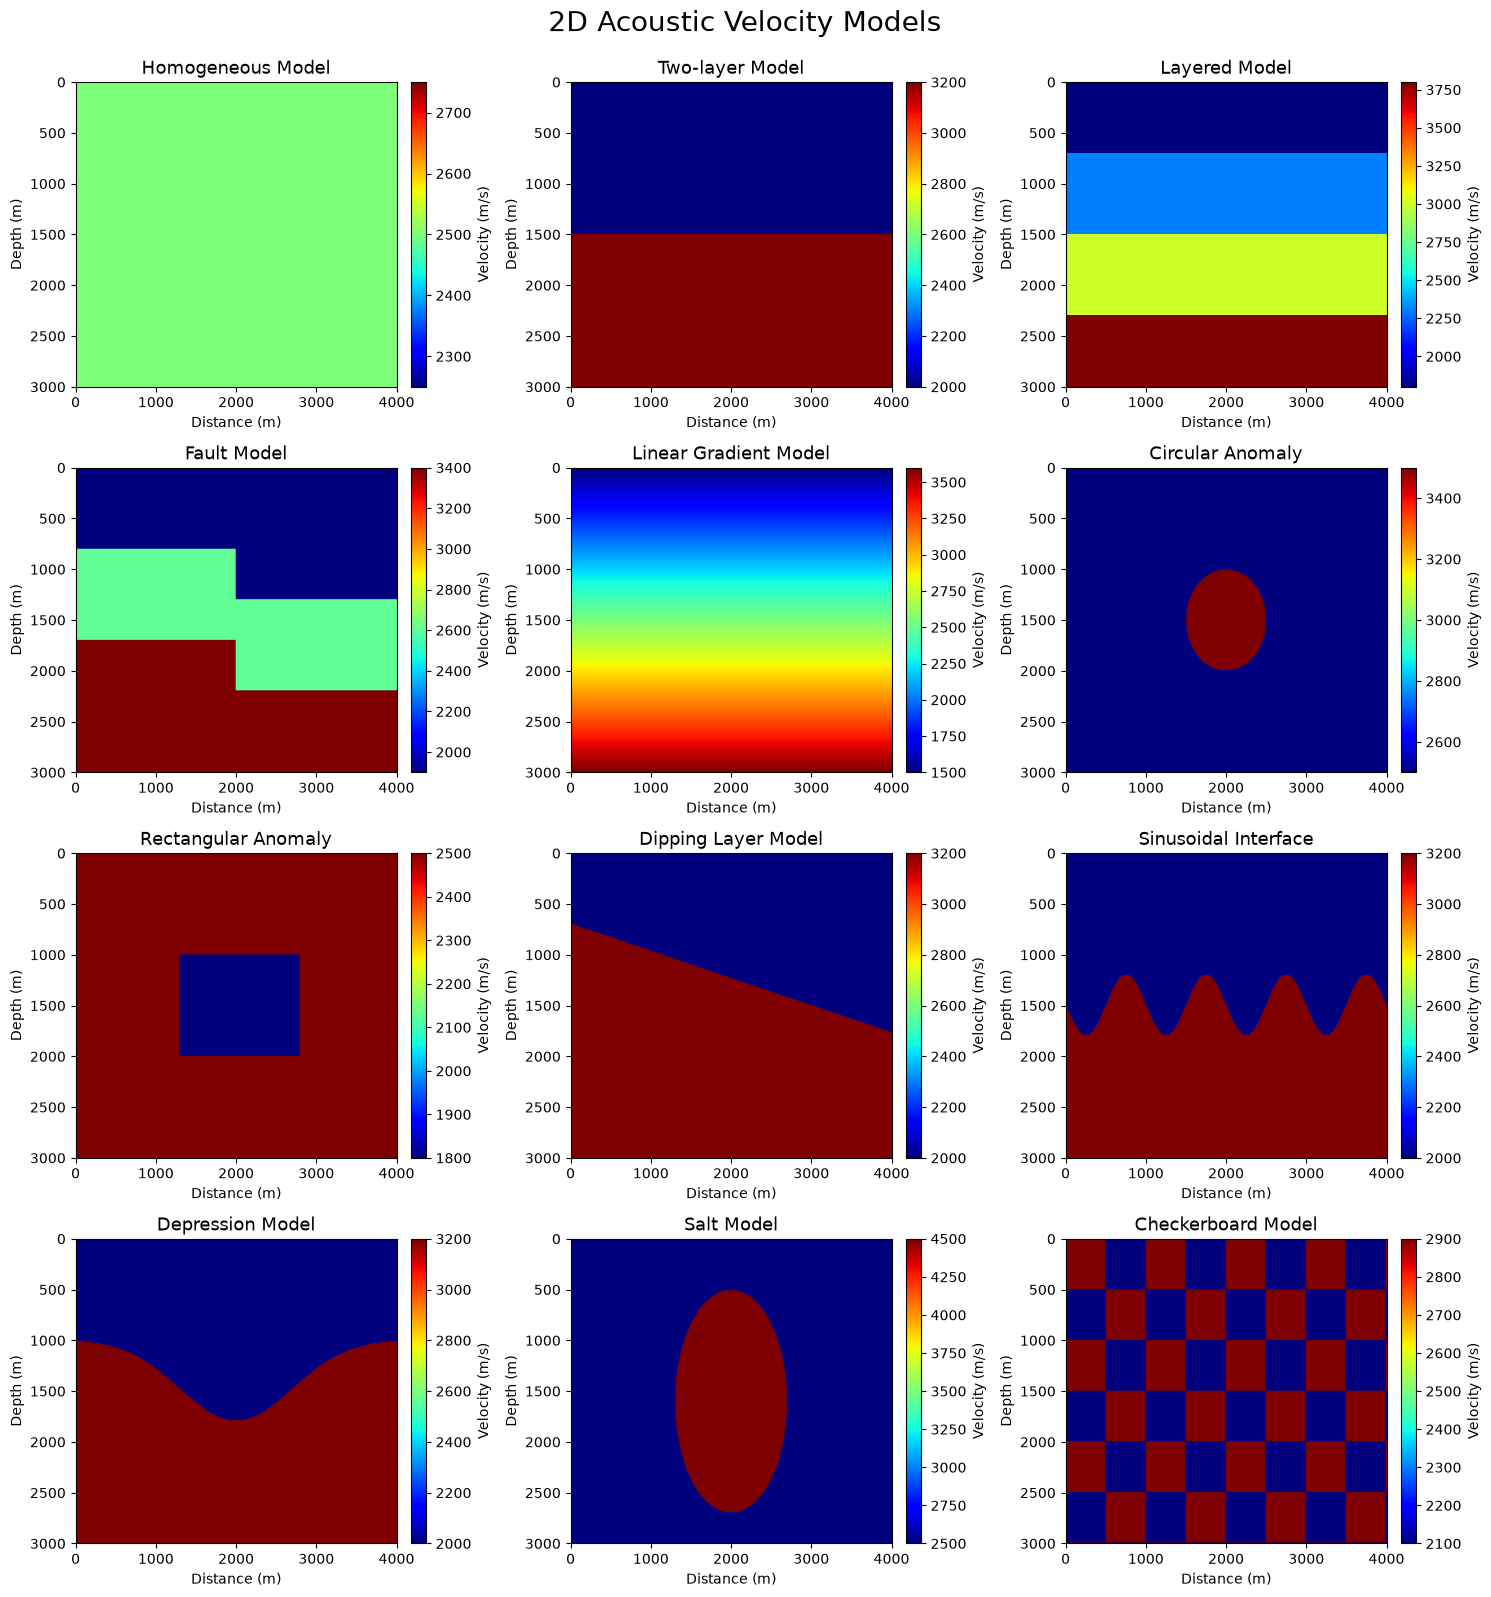

In [4]:
models = [
    vel_homo,
    vel_two_layer,
    vel_layered,
    vel_fault,
    vel_gradient,
    vel_circle,
    vel_rectangle,
    vel_dipping,
    vel_sinusoidal,
    vel_depression,
    vel_salt,
    vel_checkerboard
]

titles = [
    "Homogeneous Model",
    "Two-layer Model",
    "Layered Model",
    "Fault Model",
    "Linear Gradient Model",
    "Circular Anomaly",
    "Rectangular Anomaly",
    "Dipping Layer Model",
    "Sinusoidal Interface",
    "Depression Model",
    "Salt Model",
    "Checkerboard Model"
]

fig, axes = plt.subplots(4,3,figsize=(15, 16))
axes = axes.ravel()

for i, (vel, title) in enumerate(zip(models, titles)):
    im = axes[i].imshow(vel,extent=[0,x_max,z_max,0],aspect="auto",cmap="jet")
    axes[i].set_title(title,fontsize=13)
    axes[i].set_xlabel("Distance (m)")
    axes[i].set_ylabel("Depth (m)")
    cbar = fig.colorbar(im,ax=axes[i],fraction=0.046,pad=0.04)
    cbar.set_label("Velocity (m/s)")

for j in range(len(models), len(axes)):
    axes[j].axis("off")
fig.suptitle("2D Acoustic Velocity Models",fontsize=20,y=0.995)
plt.tight_layout()
plt.show()

In [5]:
# Gaussian smoothing
def smooth_velocity_model(velocity, sigma_x=5.0, sigma_z=3.0):
    velocity_smooth = gaussian_filter(
        velocity,
        sigma=(sigma_z, sigma_x),
        mode="nearest"
    )
    return velocity_smooth

sigma_x=5.0
sigma_z=5.0
# 1. Homogeneous model
vel_homo_smooth = smooth_velocity_model(
    vel_homo,
    sigma_x,
    sigma_z
)

# 2. Two-layer model
vel_two_layer_smooth = smooth_velocity_model(
    vel_two_layer,
    sigma_x,
    sigma_z
)

# 3. Multi-layer model
vel_layered_smooth = smooth_velocity_model(
    vel_layered,
    sigma_x,
    sigma_z
)

# 4. Fault model
vel_fault_smooth = smooth_velocity_model(
    vel_fault,
    sigma_x,
    sigma_z
)

# 5. Linear gradient model
vel_gradient_smooth = smooth_velocity_model(
    vel_gradient,
    sigma_x,
    sigma_z
)

# 6. Circular anomaly model
vel_circle_smooth = smooth_velocity_model(
    vel_circle,
    sigma_x,
    sigma_z
)

# 7. Rectangular anomaly model
vel_rectangle_smooth = smooth_velocity_model(
    vel_rectangle,
    sigma_x,
    sigma_z
)

# 8. Dipping layer model
vel_dipping_smooth = smooth_velocity_model(
    vel_dipping,
    sigma_x,
    sigma_z
)

# 9. Sinusoidal interface model
vel_sinusoidal_smooth = smooth_velocity_model(
    vel_sinusoidal,
    sigma_x,
    sigma_z
)

# 10. Depression model
vel_depression_smooth = smooth_velocity_model(
    vel_depression,
    sigma_x,
    sigma_z
)

# 11. Salt model
vel_salt_smooth = smooth_velocity_model(
    vel_salt,
    sigma_x,
    sigma_z
)

# 12. Checkerboard model
vel_checkerboard_smooth = smooth_velocity_model(
    vel_checkerboard,
    sigma_x,
    sigma_z
)

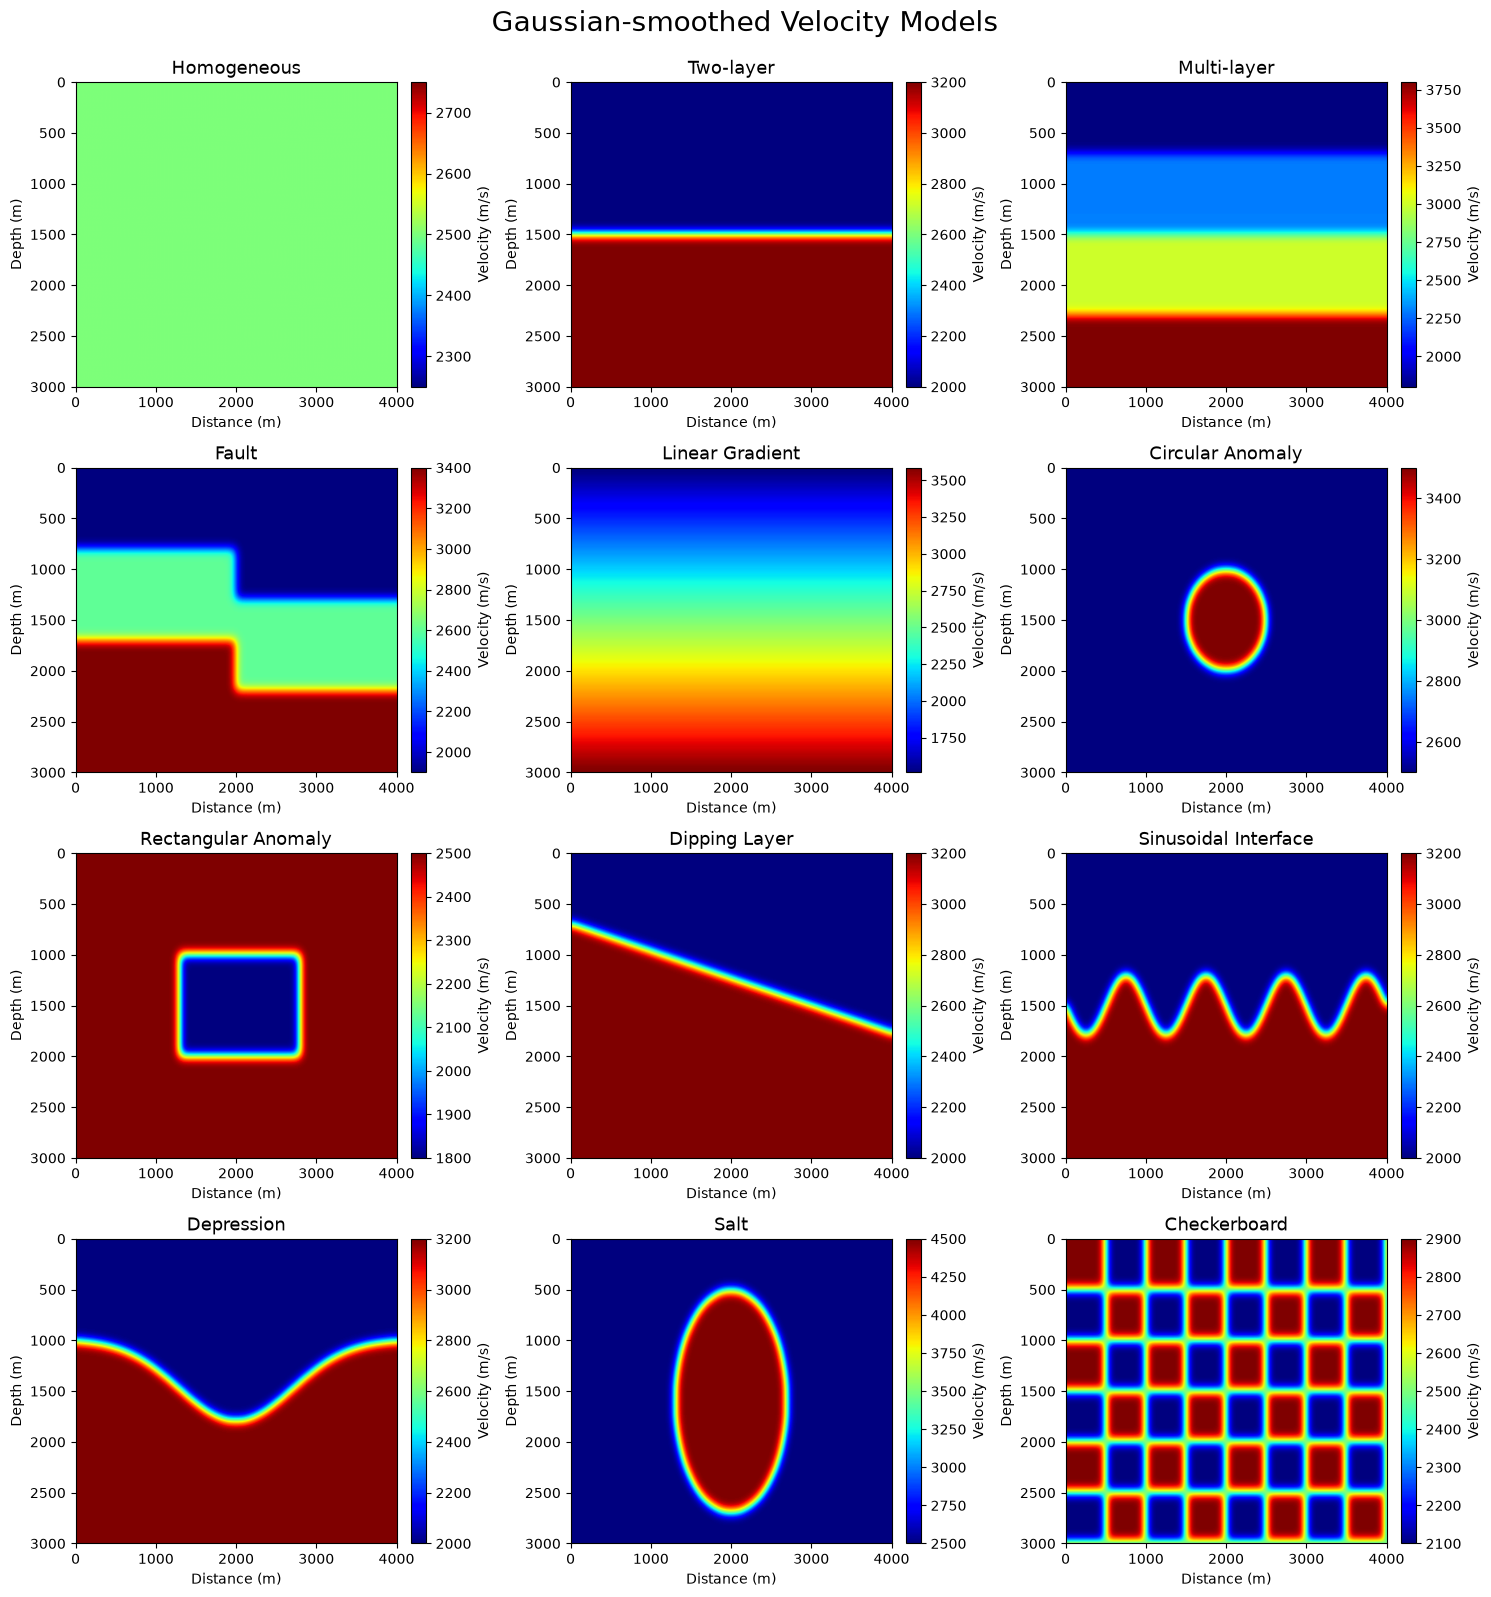

In [6]:
smooth_models = [
    vel_homo_smooth,
    vel_two_layer_smooth,
    vel_layered_smooth,
    vel_fault_smooth,
    vel_gradient_smooth,
    vel_circle_smooth,
    vel_rectangle_smooth,
    vel_dipping_smooth,
    vel_sinusoidal_smooth,
    vel_depression_smooth,
    vel_salt_smooth,
    vel_checkerboard_smooth
]

titles = [
    "Homogeneous",
    "Two-layer",
    "Multi-layer",
    "Fault",
    "Linear Gradient",
    "Circular Anomaly",
    "Rectangular Anomaly",
    "Dipping Layer",
    "Sinusoidal Interface",
    "Depression",
    "Salt",
    "Checkerboard"
]

fig, axes = plt.subplots(4,3,figsize=(15, 16))
axes = axes.ravel()

for i, (vel, title) in enumerate(zip(smooth_models, titles)):
    im = axes[i].imshow(vel,extent=[0,x_max,z_max,0],aspect="auto",cmap="jet")
    axes[i].set_title(title,fontsize=13)
    axes[i].set_xlabel("Distance (m)")
    axes[i].set_ylabel("Depth (m)")
    cbar = fig.colorbar(im,ax=axes[i],fraction=0.046,pad=0.04)
    cbar.set_label("Velocity (m/s)")

for j in range(len(models), len(axes)):
    axes[j].axis("off")
fig.suptitle("Gaussian-smoothed Velocity Models",fontsize=20,y=0.995)
plt.tight_layout()
plt.show()